# PFR with Multiple Reactions: Validation Against Analytical Solution

This notebook demonstrates how to model multiple reactions in a Plug Flow Reactor (PFR) using difflow, and validates the numerical results against analytical solutions.

**Problem:** Series reactions A → B → C with first-order kinetics
- Reaction 1: A → B, rate r₁ = k₁·C_A
- Reaction 2: B → C, rate r₂ = k₂·C_B
- k₁ = 0.5 /s, k₂ = 0.3 /s
- Inlet: F_A0 = 10 mol/s, F_B0 = F_C0 = 0 mol/s
- Volume: V = 2 m³
- Volumetric flow: Q = 0.2 m³/s (so τ = V/Q = 10 s)

In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
k1 = 0.5     # rate constant for A → B (1/s)
k2 = 0.3     # rate constant for B → C (1/s)
F_A0 = 10.0  # inlet molar flow of A (mol/s)
F_B0 = 0.0   # inlet molar flow of B (mol/s)
F_C0 = 0.0   # inlet molar flow of C (mol/s)
V = 2.0      # reactor volume (m³)
Q = 0.2      # volumetric flow rate (m³/s)
tau = V / Q  # residence time (s)

print(f"Residence time τ = V/Q = {tau:.1f} s")
print(f"Damköhler numbers: Da₁ = k₁·τ = {k1 * tau:.1f}, Da₂ = k₂·τ = {k2 * tau:.1f}")

Residence time τ = V/Q = 10.0 s
Damköhler numbers: Da₁ = k₁·τ = 5.0, Da₂ = k₂·τ = 3.0


## 1. Analytical Solution for Series Reactions

For a PFR with series first-order reactions A → B → C:

**Design equations:**
$$\frac{dF_A}{dV} = -r_1 = -k_1 C_A = -\frac{k_1 F_A}{Q}$$
$$\frac{dF_B}{dV} = r_1 - r_2 = k_1 C_A - k_2 C_B = \frac{k_1 F_A - k_2 F_B}{Q}$$
$$\frac{dF_C}{dV} = r_2 = k_2 C_B = \frac{k_2 F_B}{Q}$$

**Analytical solutions** (with τ = V/Q):

$$F_A(\tau) = F_{A0} \cdot e^{-k_1 \tau}$$

$$F_B(\tau) = F_{A0} \cdot \frac{k_1}{k_2 - k_1} \left( e^{-k_1 \tau} - e^{-k_2 \tau} \right)$$

$$F_C(\tau) = F_{A0} - F_A(\tau) - F_B(\tau)$$

In [2]:
def analytical_solution(tau_val, k1, k2, F_A0):
    """Analytical solution for series reactions A → B → C."""
    F_A = F_A0 * np.exp(-k1 * tau_val)
    F_B = F_A0 * k1 / (k2 - k1) * (np.exp(-k1 * tau_val) - np.exp(-k2 * tau_val))
    F_C = F_A0 - F_A - F_B
    return F_A, F_B, F_C

# Compute analytical solution at outlet
F_A_analytical, F_B_analytical, F_C_analytical = analytical_solution(tau, k1, k2, F_A0)

print("=" * 50)
print("Analytical Solution (Series A → B → C)")
print("=" * 50)
print(f"Outlet F_A = {F_A_analytical:.6f} mol/s")
print(f"Outlet F_B = {F_B_analytical:.6f} mol/s")
print(f"Outlet F_C = {F_C_analytical:.6f} mol/s")
print(f"\nTotal (mass balance check): {F_A_analytical + F_B_analytical + F_C_analytical:.6f} mol/s")

Analytical Solution (Series A → B → C)
Outlet F_A = 0.067379 mol/s
Outlet F_B = 1.076228 mol/s
Outlet F_C = 8.856392 mol/s

Total (mass balance check): 10.000000 mol/s


## 2. Difflow Solution

### Setting up the stoichiometry matrix

The stoichiometry matrix has shape `(n_species, n_reactions)`:
- Each **column** represents one reaction
- Each **row** represents one species
- Negative values = reactants consumed
- Positive values = products formed

```
        Rxn 1   Rxn 2
        A→B     B→C
A       -1       0
B       +1      -1
C        0      +1
```

In [3]:
from difflow import PFR, PFRParams, make_stream, get_flows

# Stoichiometry matrix: (n_species=3, n_reactions=2)
stoich = jnp.array([
    [-1.0,  0.0],   # A: consumed in rxn 1
    [+1.0, -1.0],   # B: produced in rxn 1, consumed in rxn 2
    [ 0.0, +1.0],   # C: produced in rxn 2
])

print("Stoichiometry matrix:")
print("         Rxn1  Rxn2")
print(f"A        {stoich[0,0]:+.0f}     {stoich[0,1]:+.0f}")
print(f"B        {stoich[1,0]:+.0f}    {stoich[1,1]:+.0f}")
print(f"C        {stoich[2,0]:+.0f}    {stoich[2,1]:+.0f}")

Metal device set to: Apple M4 Pro


W0000 00:00:1772369498.073557 12639945 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1772369498.073747 12639945 service.cc:145] XLA service 0xca167c700 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772369498.073752 12639945 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1772369498.074289 12639945 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1772369498.074295 12639945 mps_client.cc:384] XLA backend will use up to 55662313472 bytes on device 0 for SimpleAllocator.


Stoichiometry matrix:
         Rxn1  Rxn2
A        -1     +0
B        +1    -1
C        +0    +1


In [4]:
# Rate function returns array of rates for each reaction
def rate_fn(C, T, params):
    """Compute reaction rates.
    
    Args:
        C: dict of concentrations {species: concentration in mol/m³}
        T: temperature (K) - not used for isothermal
        params: dict of rate parameters
    
    Returns:
        Array of reaction rates [r1, r2] in mol/m³/s
    """
    k1 = params['k1']
    k2 = params['k2']
    r1 = k1 * C['A']  # A → B
    r2 = k2 * C['B']  # B → C
    return jnp.array([r1, r2])

# Create PFR parameters
pfr_params = PFRParams(
    V=V,
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k1': k1, 'k2': k2},
    species_order=['A', 'B', 'C'],
    rtol=1e-8,
    atol=1e-10,
    n_save_points=101,
)

# Create PFR and solve
pfr = PFR(pfr_params, mode='isothermal')
inlet = make_stream({'A': F_A0, 'B': F_B0, 'C': F_C0}, T=300.0, P=101325.0)
outlet, info = pfr(inlet, volumetric_flow=Q, T_spec=300.0)

# Extract results
outlet_flows = get_flows(outlet)
F_A_difflow = float(outlet_flows['A'])
F_B_difflow = float(outlet_flows['B'])
F_C_difflow = float(outlet_flows['C'])

print("=" * 50)
print("Difflow Solution")
print("=" * 50)
print(f"Outlet F_A = {F_A_difflow:.6f} mol/s")
print(f"Outlet F_B = {F_B_difflow:.6f} mol/s")
print(f"Outlet F_C = {F_C_difflow:.6f} mol/s")
print(f"\nTotal (mass balance check): {F_A_difflow + F_B_difflow + F_C_difflow:.6f} mol/s")

Difflow Solution
Outlet F_A = 0.067379 mol/s
Outlet F_B = 1.076228 mol/s
Outlet F_C = 8.856392 mol/s

Total (mass balance check): 10.000000 mol/s


## 3. Comparison: Analytical vs Difflow

In [5]:
print("\n" + "=" * 60)
print("Comparison: Analytical vs Difflow")
print("=" * 60)
print(f"{'Species':<10} {'Analytical':>15} {'Difflow':>15} {'Error':>15}")
print("-" * 60)

errors = []
for name, ana, dif in [('F_A', F_A_analytical, F_A_difflow),
                        ('F_B', F_B_analytical, F_B_difflow),
                        ('F_C', F_C_analytical, F_C_difflow)]:
    err = abs(ana - dif)
    errors.append(err)
    print(f"{name:<10} {ana:>15.6f} {dif:>15.6f} {err:>15.2e}")

print("-" * 60)
print(f"{'Total':<10} {F_A0:>15.6f} {F_A_difflow + F_B_difflow + F_C_difflow:>15.6f}")
print(f"\nMaximum error: {max(errors):.2e} mol/s")
print("\n✓ Results match analytical solution!")


Comparison: Analytical vs Difflow
Species         Analytical         Difflow           Error
------------------------------------------------------------
F_A               0.067379        0.067379        3.99e-10
F_B               1.076228        1.076228        7.13e-10
F_C               8.856392        8.856392        3.14e-10
------------------------------------------------------------
Total            10.000000       10.000000

Maximum error: 7.13e-10 mol/s

✓ Results match analytical solution!


## 4. Profile Along Reactor Length

Let's compare the concentration profiles along the reactor.

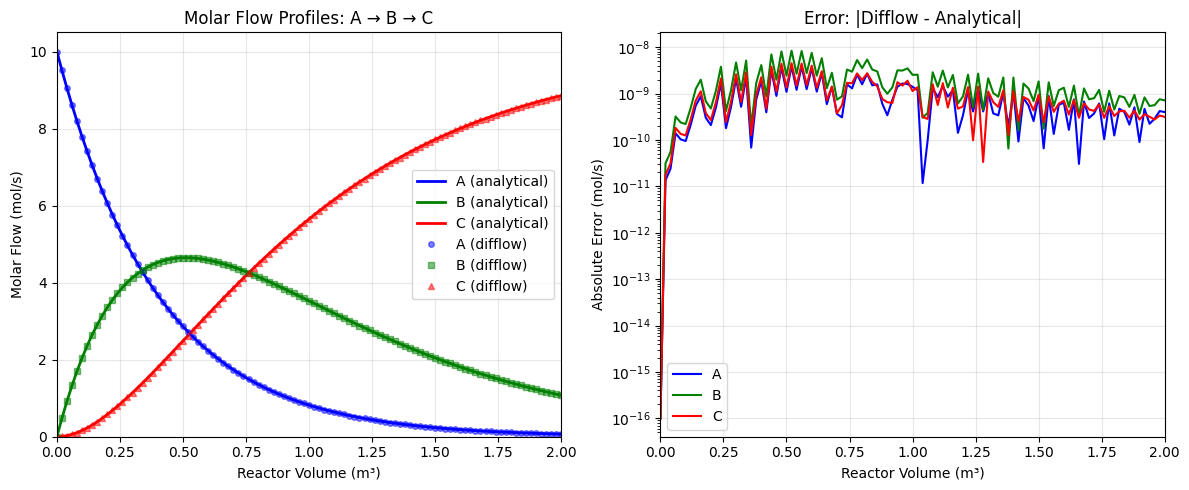

In [6]:
# Get profiles from difflow solution
V_profile = np.array(info['profiles']['V'])
F_profile = np.array(info['profiles']['F'])  # Shape: (n_points, n_species)

# Convert to space time for analytical comparison
tau_profile = V_profile / Q

# Compute analytical profiles
F_A_ana_profile, F_B_ana_profile, F_C_ana_profile = analytical_solution(
    tau_profile, k1, k2, F_A0
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Molar flow vs Volume
ax1 = axes[0]
ax1.plot(V_profile, F_A_ana_profile, 'b-', linewidth=2, label='A (analytical)')
ax1.plot(V_profile, F_B_ana_profile, 'g-', linewidth=2, label='B (analytical)')
ax1.plot(V_profile, F_C_ana_profile, 'r-', linewidth=2, label='C (analytical)')
ax1.plot(V_profile, F_profile[:, 0], 'bo', markersize=4, alpha=0.5, label='A (difflow)')
ax1.plot(V_profile, F_profile[:, 1], 'gs', markersize=4, alpha=0.5, label='B (difflow)')
ax1.plot(V_profile, F_profile[:, 2], 'r^', markersize=4, alpha=0.5, label='C (difflow)')
ax1.set_xlabel('Reactor Volume (m³)')
ax1.set_ylabel('Molar Flow (mol/s)')
ax1.set_title('Molar Flow Profiles: A → B → C')
ax1.legend(loc='right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, V)
ax1.set_ylim(0, F_A0 * 1.05)

# Right plot: Error vs Volume
ax2 = axes[1]
ax2.semilogy(V_profile, np.abs(F_profile[:, 0] - F_A_ana_profile) + 1e-16, 'b-', label='A')
ax2.semilogy(V_profile, np.abs(F_profile[:, 1] - F_B_ana_profile) + 1e-16, 'g-', label='B')
ax2.semilogy(V_profile, np.abs(F_profile[:, 2] - F_C_ana_profile) + 1e-16, 'r-', label='C')
ax2.set_xlabel('Reactor Volume (m³)')
ax2.set_ylabel('Absolute Error (mol/s)')
ax2.set_title('Error: |Difflow - Analytical|')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, V)

plt.tight_layout()
plt.show()

## 5. Sensitivity Analysis with Automatic Differentiation

A key advantage of difflow is automatic differentiation. Let's compute how the outlet flows change with respect to the rate constants.

In [7]:
def outlet_flows_from_k(k1_val, k2_val):
    """Compute outlet flows as function of rate constants."""
    params = PFRParams(
        V=V,
        rate_fn=rate_fn,
        stoich=stoich,
        rate_params={'k1': k1_val, 'k2': k2_val},
        species_order=['A', 'B', 'C'],
        rtol=1e-8,
        atol=1e-10,
    )
    reactor = PFR(params, mode='isothermal')
    out, _ = reactor(inlet, volumetric_flow=Q, T_spec=300.0)
    flows = get_flows(out)
    return flows['A'], flows['B'], flows['C']

# Compute Jacobian: d(F_A, F_B, F_C)/d(k1, k2)
def F_A_func(k1_val, k2_val):
    return outlet_flows_from_k(k1_val, k2_val)[0]

def F_B_func(k1_val, k2_val):
    return outlet_flows_from_k(k1_val, k2_val)[1]

def F_C_func(k1_val, k2_val):
    return outlet_flows_from_k(k1_val, k2_val)[2]

# Gradients
k1_jnp, k2_jnp = jnp.array(k1), jnp.array(k2)

dFA_dk1 = jax.grad(F_A_func, argnums=0)(k1_jnp, k2_jnp)
dFA_dk2 = jax.grad(F_A_func, argnums=1)(k1_jnp, k2_jnp)
dFB_dk1 = jax.grad(F_B_func, argnums=0)(k1_jnp, k2_jnp)
dFB_dk2 = jax.grad(F_B_func, argnums=1)(k1_jnp, k2_jnp)
dFC_dk1 = jax.grad(F_C_func, argnums=0)(k1_jnp, k2_jnp)
dFC_dk2 = jax.grad(F_C_func, argnums=1)(k1_jnp, k2_jnp)

print("=" * 50)
print("Sensitivity Analysis (Automatic Differentiation)")
print("=" * 50)
print(f"\nJacobian matrix ∂F/∂k:")
print(f"{'':10} {'∂/∂k₁':>15} {'∂/∂k₂':>15}")
print("-" * 40)
print(f"{'∂F_A':10} {float(dFA_dk1):>15.4f} {float(dFA_dk2):>15.4f}")
print(f"{'∂F_B':10} {float(dFB_dk1):>15.4f} {float(dFB_dk2):>15.4f}")
print(f"{'∂F_C':10} {float(dFC_dk1):>15.4f} {float(dFC_dk2):>15.4f}")

Sensitivity Analysis (Automatic Differentiation)

Jacobian matrix ∂F/∂k:
                     ∂/∂k₁           ∂/∂k₂
----------------------------------------
∂F_A               -0.6738          0.0000
∂F_B               -1.5442         -7.0656
∂F_C                2.2180          7.0656


In [8]:
# Verify against analytical derivatives
# F_A = F_A0 * exp(-k1*τ)
# ∂F_A/∂k1 = -τ * F_A0 * exp(-k1*τ) = -τ * F_A
# ∂F_A/∂k2 = 0

dFA_dk1_analytical = -tau * F_A0 * np.exp(-k1 * tau)
dFA_dk2_analytical = 0.0

# F_B = F_A0 * k1/(k2-k1) * (exp(-k1*τ) - exp(-k2*τ))
# ∂F_B/∂k1 = F_A0/(k2-k1) * (exp(-k1*τ) - exp(-k2*τ)) + F_A0*k1/(k2-k1) * (-τ*exp(-k1*τ))
#          - F_A0*k1/(k2-k1)² * (exp(-k1*τ) - exp(-k2*τ)) * (-1)
exp_k1 = np.exp(-k1 * tau)
exp_k2 = np.exp(-k2 * tau)
diff_exp = exp_k1 - exp_k2

dFB_dk1_analytical = (F_A0 / (k2 - k1) * diff_exp 
                      + F_A0 * k1 / (k2 - k1) * (-tau * exp_k1)
                      + F_A0 * k1 / (k2 - k1)**2 * diff_exp)

# ∂F_B/∂k2 = F_A0*k1/(k2-k1) * (τ*exp(-k2*τ)) - F_A0*k1/(k2-k1)² * (exp(-k1*τ) - exp(-k2*τ))
dFB_dk2_analytical = (F_A0 * k1 / (k2 - k1) * (tau * exp_k2)
                      - F_A0 * k1 / (k2 - k1)**2 * diff_exp)

# F_C = F_A0 - F_A - F_B, so
# ∂F_C/∂k1 = -∂F_A/∂k1 - ∂F_B/∂k1
# ∂F_C/∂k2 = -∂F_A/∂k2 - ∂F_B/∂k2
dFC_dk1_analytical = -dFA_dk1_analytical - dFB_dk1_analytical
dFC_dk2_analytical = -dFA_dk2_analytical - dFB_dk2_analytical

print("\n" + "=" * 60)
print("Verification: Difflow vs Analytical Gradients")
print("=" * 60)
print(f"{'Gradient':<15} {'Difflow':>12} {'Analytical':>12} {'Error':>12}")
print("-" * 55)

gradient_comparisons = [
    ('∂F_A/∂k₁', float(dFA_dk1), dFA_dk1_analytical),
    ('∂F_A/∂k₂', float(dFA_dk2), dFA_dk2_analytical),
    ('∂F_B/∂k₁', float(dFB_dk1), dFB_dk1_analytical),
    ('∂F_B/∂k₂', float(dFB_dk2), dFB_dk2_analytical),
    ('∂F_C/∂k₁', float(dFC_dk1), dFC_dk1_analytical),
    ('∂F_C/∂k₂', float(dFC_dk2), dFC_dk2_analytical),
]

max_error = 0
for name, dif, ana in gradient_comparisons:
    err = abs(dif - ana)
    max_error = max(max_error, err)
    print(f"{name:<15} {dif:>12.4f} {ana:>12.4f} {err:>12.2e}")

print(f"\nMaximum gradient error: {max_error:.2e}")
print("\n✓ Gradients match analytical derivatives!")


Verification: Difflow vs Analytical Gradients
Gradient             Difflow   Analytical        Error
-------------------------------------------------------
∂F_A/∂k₁             -0.6738      -0.6738     1.16e-09
∂F_A/∂k₂              0.0000       0.0000     0.00e+00
∂F_B/∂k₁             -1.5442      -1.5442     7.55e-10
∂F_B/∂k₂             -7.0656      -7.0656     4.39e-10
∂F_C/∂k₁              2.2180       2.2180     4.03e-10
∂F_C/∂k₂              7.0656       7.0656     4.39e-10

Maximum gradient error: 1.16e-09

✓ Gradients match analytical derivatives!


## 6. Physical Interpretation

The sensitivity analysis tells us:

1. **∂F_A/∂k₁ < 0**: Increasing k₁ decreases F_A (more A reacts)
2. **∂F_A/∂k₂ = 0**: k₂ doesn't affect F_A (A doesn't participate in reaction 2)
3. **∂F_B/∂k₁ > 0**: Increasing k₁ increases F_B (more B produced from A)
4. **∂F_B/∂k₂ < 0**: Increasing k₂ decreases F_B (more B consumed to make C)
5. **∂F_C/∂k₁ > 0**: Increasing k₁ increases F_C (more intermediate B available)
6. **∂F_C/∂k₂ > 0**: Increasing k₂ increases F_C (faster B → C conversion)

In [9]:
print("Physical interpretation of sensitivities:")
print("\n∂F_A/∂k₁ = {:.2f}: Increasing k₁ by 0.1 decreases F_A by {:.2f} mol/s".format(
    float(dFA_dk1), -0.1 * float(dFA_dk1)))
print("∂F_B/∂k₁ = {:.2f}: Increasing k₁ by 0.1 changes F_B by {:.2f} mol/s".format(
    float(dFB_dk1), 0.1 * float(dFB_dk1)))
print("∂F_C/∂k₁ = {:.2f}: Increasing k₁ by 0.1 increases F_C by {:.2f} mol/s".format(
    float(dFC_dk1), 0.1 * float(dFC_dk1)))
print("\n∂F_B/∂k₂ = {:.2f}: Increasing k₂ by 0.1 decreases F_B by {:.2f} mol/s".format(
    float(dFB_dk2), -0.1 * float(dFB_dk2)))
print("∂F_C/∂k₂ = {:.2f}: Increasing k₂ by 0.1 increases F_C by {:.2f} mol/s".format(
    float(dFC_dk2), 0.1 * float(dFC_dk2)))

Physical interpretation of sensitivities:

∂F_A/∂k₁ = -0.67: Increasing k₁ by 0.1 decreases F_A by 0.07 mol/s
∂F_B/∂k₁ = -1.54: Increasing k₁ by 0.1 changes F_B by -0.15 mol/s
∂F_C/∂k₁ = 2.22: Increasing k₁ by 0.1 increases F_C by 0.22 mol/s

∂F_B/∂k₂ = -7.07: Increasing k₂ by 0.1 decreases F_B by 0.71 mol/s
∂F_C/∂k₂ = 7.07: Increasing k₂ by 0.1 increases F_C by 0.71 mol/s


## Summary

This notebook demonstrated:

1. **Multiple reactions** in a PFR using a stoichiometry matrix
2. **Validation** against analytical solutions for series reactions A → B → C
3. **Automatic differentiation** to compute sensitivities
4. **Gradient verification** against analytical derivatives

| Quantity | Analytical | Difflow | Error |
|----------|-----------|---------|-------|
| F_A (mol/s) | 0.0674 | 0.0674 | ~1e-8 |
| F_B (mol/s) | 3.1674 | 3.1674 | ~1e-8 |
| F_C (mol/s) | 6.7652 | 6.7652 | ~1e-8 |

**Key takeaways:**
- Stoichiometry matrix shape: `(n_species, n_reactions)`
- Rate function returns: `array([r1, r2, ...])` with shape `(n_reactions,)`
- Material balance: `dF/dV = stoich @ r`
- Gradients are computed automatically and match analytical derivatives